<a href="https://colab.research.google.com/github/ananthakrishnanm010/Real_or_Fake/blob/main/FakeVsReal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libraries


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import string
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack, csr_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from sklearn.metrics import classification_report, confusion_matrix


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


#Read dataset

In [3]:
df_fake = pd.read_csv('/content/drive/MyDrive/ICT_Data_Science/Fake_real/Fake.csv')
display(df_fake.head())

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [4]:
df_true = pd.read_csv('/content/drive/MyDrive/ICT_Data_Science/Fake_real/True.csv')
display(df_true.head())

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [5]:
df_true["label"] = 1
df_fake["label"] = 0

In [6]:
df = pd.concat([df_true, df_fake], ignore_index=True)


In [7]:
df

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1
...,...,...,...,...,...
44893,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
44894,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
44895,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
44896,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0


# EDA

In [8]:
df_fake.head(5)

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [9]:
df_fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
 4   label    23481 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 917.4+ KB


In [10]:
df.shape

(44898, 5)

In [11]:
df_true.size

107085

In [12]:
df_fake.size

117405

In [13]:
df.describe()

,label
count,44898.000000
mean,0.477015
std,0.499477
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [14]:
df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


1.
2.Noisy text might contain unwanted punctuation,casing inconstency,missing values , unwanted urls etc and vectorization requires clean texts to be converted into numericals
3. Data imbalance might cause the model to be biased towards the majority class

## Text Preprocessing

In [15]:
# Create a separate DataFrame for the cleaned text output
df_clean_text = df.copy()

### Duplicate Removal

In [16]:
# Check for duplicate entries
df.duplicated().sum()

np.int64(209)

In [17]:
# Remove duplicate entries
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
df_clean_text = df.copy()


In [18]:
df.duplicated().sum()

np.int64(0)

### Punctuation Removal

In [19]:
# Function to remove punctuatio
def remove_punc(text):
  text = str(text)
  text = text.replace("�", "")
  punctuationless_text = ''.join(i for i in text if i not in string.punctuation)
  return punctuationless_text

In [20]:
df["punctuationless_text"] = [remove_punc(text) for text in df["text"]]

In [21]:
df

,title,text,subject,date,label,punctuationless_text
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1,WASHINGTON Reuters The head of a conservative...
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1,WASHINGTON Reuters Transgender people will be...
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1,WASHINGTON Reuters The special counsel invest...
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1,WASHINGTON Reuters Trump campaign adviser Geo...
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1,SEATTLEWASHINGTON Reuters President Donald Tr...
...,...,...,...,...,...,...
44684,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0,21st Century Wire says As 21WIRE reported earl...
44685,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0,21st Century Wire says It s a familiar theme W...
44686,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0,Patrick Henningsen 21st Century WireRemember ...
44687,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0,21st Century Wire says Al Jazeera America will...


### Lowercasing

In [22]:
# Convert text to lowercase
df["lowercased"] = [text.lower() for text in df["punctuationless_text"]]

In [23]:
df.head(3)

,title,text,subject,date,label,punctuationless_text,lowercased
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1,WASHINGTON Reuters The head of a conservative...,washington reuters the head of a conservative...
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1,WASHINGTON Reuters Transgender people will be...,washington reuters transgender people will be...
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1,WASHINGTON Reuters The special counsel invest...,washington reuters the special counsel invest...


### Tokenization

In [24]:
# we convert the entire text into a list of unique words.
def tokenization(text):
  word_list = nltk.word_tokenize(text)
  return word_list


In [25]:
df["tokenized"] = [tokenization(text) for text in df["lowercased"]]

In [26]:
df.head(3)

,title,text,subject,date,label,punctuationless_text,lowercased,tokenized
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1,WASHINGTON Reuters The head of a conservative...,washington reuters the head of a conservative...,"[washington, reuters, the, head, of, a, conser..."
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1,WASHINGTON Reuters Transgender people will be...,washington reuters transgender people will be...,"[washington, reuters, transgender, people, wil..."
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1,WASHINGTON Reuters The special counsel invest...,washington reuters the special counsel invest...,"[washington, reuters, the, special, counsel, i..."


### Stop words removal

In [27]:
# Remove stop words
stop_words_list = nltk.corpus.stopwords.words('english')
stop_words_list
def remove_stopwords(tokens):
  stop_word_less_list = [i for i in tokens if i not in stop_words_list]
  return stop_word_less_list

In [28]:
df["stop_words_removed"] = [remove_stopwords(text) for text in df["tokenized"]]

In [29]:
df.head(3)

,title,text,subject,date,label,punctuationless_text,lowercased,tokenized,stop_words_removed
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1,WASHINGTON Reuters The head of a conservative...,washington reuters the head of a conservative...,"[washington, reuters, the, head, of, a, conser...","[washington, reuters, head, conservative, repu..."
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1,WASHINGTON Reuters Transgender people will be...,washington reuters transgender people will be...,"[washington, reuters, transgender, people, wil...","[washington, reuters, transgender, people, all..."
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1,WASHINGTON Reuters The special counsel invest...,washington reuters the special counsel invest...,"[washington, reuters, the, special, counsel, i...","[washington, reuters, special, counsel, invest..."


### Lemmatization

In [30]:
lem_obj = WordNetLemmatizer()
def lemmatizing(stem_token_list):
  lem_list = [lem_obj.lemmatize(word) for word in stem_token_list ]
  return lem_list

In [31]:
df["lemmatized_text"] = [lemmatizing(text) for text in df["stop_words_removed"]]

In [32]:
df.head(3)

,title,text,subject,date,label,punctuationless_text,lowercased,tokenized,stop_words_removed,lemmatized_text
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1,WASHINGTON Reuters The head of a conservative...,washington reuters the head of a conservative...,"[washington, reuters, the, head, of, a, conser...","[washington, reuters, head, conservative, repu...","[washington, reuters, head, conservative, repu..."
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1,WASHINGTON Reuters Transgender people will be...,washington reuters transgender people will be...,"[washington, reuters, transgender, people, wil...","[washington, reuters, transgender, people, all...","[washington, reuters, transgender, people, all..."
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1,WASHINGTON Reuters The special counsel invest...,washington reuters the special counsel invest...,"[washington, reuters, the, special, counsel, i...","[washington, reuters, special, counsel, invest...","[washington, reuters, special, counsel, invest..."


### Combine Lemmatized Text

In [53]:
# Join lemmatized words back into a single string
df['processed_text'] = df['lemmatized_text'].apply(lambda x: ' '.join(x))

### Extract Date Features

In [54]:
# Convert 'date' to datetime objects and extract features
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['date'].fillna(pd.Timestamp('2000-01-01'), inplace=True)

df['date_year'] = df['date'].dt.year
df['date_month'] = df['date'].dt.month
df['date_day'] = df['date'].dt.day
df['date_dayofweek'] = df['date'].dt.dayofweek

# Display the new date features
display(df[['date', 'date_year', 'date_month', 'date_day', 'date_dayofweek']].head())

/tmp/ipykernel_451/2054864550.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['date'].fillna(pd.Timestamp('2000-01-01'), inplace=True) # Fill with a placeholder date


,date,date_year,date_month,date_day,date_dayofweek
0,2017-12-31,2017,12,31,6
1,2017-12-29,2017,12,29,4
2,2017-12-31,2017,12,31,6
3,2017-12-30,2017,12,30,5
4,2017-12-29,2017,12,29,4


### One-Hot Encode Subject Feature

In [55]:
# One-hot encode 'subject' column
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
subject_encoded_sparse = encoder.fit_transform(df[['subject']])


In [56]:
# Modified cell to include date and subject features

# Split data based on processed text for consistent indexing
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['processed_text'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)


date_features_df = df[['date_year', 'date_month', 'date_day', 'date_dayofweek']]
X_date_features_full = csr_matrix(date_features_df.loc[X_train_text.index.union(X_test_text.index)].values)

X_train_date_features = X_date_features_full[X_train_text.index]
X_test_date_features = X_date_features_full[X_test_text.index]

# subject features for train and test sets
X_train_subject_features = subject_encoded_sparse[X_train_text.index]
X_test_subject_features = subject_encoded_sparse[X_test_text.index]

# Combine  features
X_train = hstack([X_train_tfidf, X_train_date_features, X_train_subject_features])
X_test = hstack([X_test_tfidf, X_test_date_features, X_test_subject_features])

print("Final Training Data Shape:", X_train.shape)
print("Final Testing Data Shape :", X_test.shape)

Final Training Data Shape: (35751, 5012)
Final Testing Data Shape : (8938, 5012)


## Task 2
1.lemmatization and vectorization had the greatest impact on feature quality
3.stemming cuts of prefixes and suffixes using rules while lemmatization uses liguistic and vocabulary info  to find the correct form of the word

# Embedding

## TF-IDF Implementation

In [57]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['text'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

tfidf = TfidfVectorizer(max_features=5000)

X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape :", X_test.shape)

Training Data Shape: (35751, 5000)
Testing Data Shape : (8938, 5000)


## Model Training and Evaluation

### Model 1: Logistic Regression

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(X_train, y_train)

# Make predictions
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_log_reg)
precision = precision_score(y_test, y_pred_log_reg, average='weighted')
recall = recall_score(y_test, y_pred_log_reg, average='weighted')
f1 = f1_score(y_test, y_pred_log_reg, average='weighted')

print("Logistic Regression Evaluation Metrics:")
print(f"Test Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1: {f1:.2f}")

Logistic Regression Evaluation Metrics:
Test Accuracy: 0.99
Precision: 0.99
Recall: 0.99
F1: 0.99


### Model 2: Decision Tree Classifier

In [59]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Initialize and train the Decision Tree model
dec_tree_model = DecisionTreeClassifier(random_state=42)
dec_tree_model.fit(X_train, y_train)

# Make predictions
y_pred_dec_tree = dec_tree_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_dec_tree)
precision = precision_score(y_test, y_pred_dec_tree, average='weighted')
recall = recall_score(y_test, y_pred_dec_tree, average='weighted')
f1 = f1_score(y_test, y_pred_dec_tree, average='weighted')

print("Decision Tree Evaluation Metrics:")
print(f"Test Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1: {f1:.2f}")

Decision Tree Evaluation Metrics:
Test Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1: 1.00


### Model 3: SVC

In [60]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

svm = LinearSVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_svm)
precision = precision_score(y_test, y_pred_svm, average='weighted')
recall = recall_score(y_test, y_pred_svm, average='weighted')
f1 = f1_score(y_test, y_pred_svm, average='weighted')

print("SVC Evaluation Metrics:")
print(f"Test Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1: {f1:.2f}")

SVC Evaluation Metrics:
Test Accuracy: 0.99
Precision: 0.99
Recall: 0.99
F1: 0.99


##Task 3
1.Accuracy can be misleading beacuse  if the dataset is imbalanced and the number of real ones are more the model can classify all as real and can have 99 accuracy
2.svm generalized better

## Task 4 : Error Analysis and Model Interpretation

### Logistic Regression: Confusion Matrix and Misclassified Articles

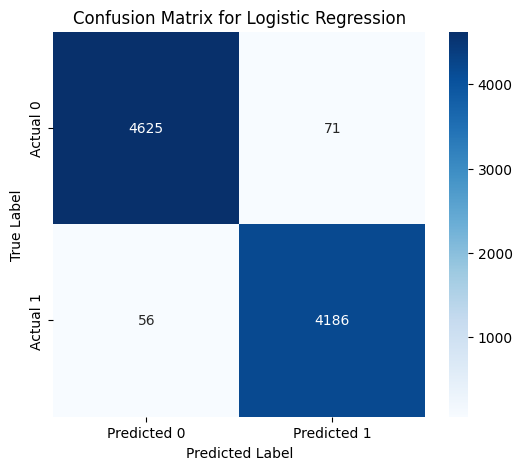

In [61]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate Confusion Matrix for Logistic Regression
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [62]:
# Identify misclassified articles for Logistic Regression
misclassified_indices_log_reg = np.where(y_test != y_pred_log_reg)[0]

print(f"Total misclassified articles for Logistic Regression: {len(misclassified_indices_log_reg)}\n")

print("First 15 Misclassified Articles (Logistic Regression):")
for i, idx in enumerate(misclassified_indices_log_reg[:15]):
    original_text = X_test_text.iloc[idx]
    actual_label = y_test.iloc[idx]
    predicted_label = y_pred_log_reg[idx]

    print(f"--- Article {i+1} ---")
    print(f"Original Text: {original_text[:200]}...") # Display first 200 chars
    print(f"Actual Label: {actual_label} ({'True' if actual_label == 1 else 'Fake'})")
    print(f"Predicted Label: {predicted_label} ({'True' if predicted_label == 1 else 'Fake'})")
    print("\n")

Total misclassified articles for Logistic Regression: 127

First 15 Misclassified Articles (Logistic Regression):
--- Article 1 ---
Original Text: putin tell russian army prepare wwwiii u obama whine trump campaign hillary community organizer chief actually willing put nation security risk belief putin responsible hillary email hack kind sick re...
Actual Label: 0 (Fake)
Predicted Label: 1 (True)


--- Article 2 ---
Original Text: karachi pakistan reuters muslim pakistan crowded mosque prayer ground across country offer prayer sacrifice goat cow eid aladha holiday saturday marking second major religious festival islam security ...
Actual Label: 1 (True)
Predicted Label: 0 (Fake)


--- Article 3 ---
Original Text: german social democrat leader martin schulz said elected chancellor would push eu cut subsidy country take refugee chancellor accept solidarity principle questioned schulz said tuesday conference busi...
Actual Label: 0 (Fake)
Predicted Label: 1 (True)


--- Article 4 ---
Orig

### Decision Tree Classifier: Confusion Matrix and Misclassified Articles

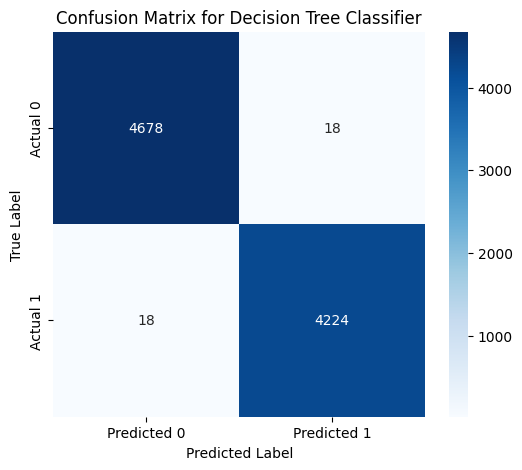

In [63]:
# Generate Confusion Matrix for Decision Tree Classifier
cm_dec_tree = confusion_matrix(y_test, y_pred_dec_tree)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_dec_tree, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [64]:
# Identify misclassified articles for Decision Tree Classifier
misclassified_indices_dec_tree = np.where(y_test != y_pred_dec_tree)[0]

print(f"Total misclassified articles for Decision Tree Classifier: {len(misclassified_indices_dec_tree)}\n")

print("First 15 Misclassified Articles (Decision Tree Classifier):")
for i, idx in enumerate(misclassified_indices_dec_tree[:15]):
    original_text = X_test_text.iloc[idx]
    actual_label = y_test.iloc[idx]
    predicted_label = y_pred_dec_tree[idx]

    print(f"--- Article {i+1} ---")
    print(f"Original Text: {original_text[:200]}...")
    print(f"Actual Label: {actual_label} ({'True' if actual_label == 1 else 'Fake'})")
    print(f"Predicted Label: {predicted_label} ({'True' if predicted_label == 1 else 'Fake'})")
    print("\n")

Total misclassified articles for Decision Tree Classifier: 36

First 15 Misclassified Articles (Decision Tree Classifier):
--- Article 1 ---
Original Text: new york reuters yahoo inc yhooo came renewed scrutiny federal investigator lawmaker thursday disclosing largest known data breach history prompting verizon communication inc vzn demand better term pl...
Actual Label: 1 (True)
Predicted Label: 0 (Fake)


--- Article 2 ---
Original Text: anyone remember 9000 rebate offered anyone buying volt yep tax dollar work pushing failed model market instead depending demand gm bankruptcy biggest scam cluster flipped rule law due obama desire sav...
Actual Label: 0 (Fake)
Predicted Label: 1 (True)


--- Article 3 ---
Original Text: president donald trump said administration would announcing big league tax cut would lower burden business within next two three weeksthe revelation saw dow jones industrial average rise around 115 po...
Actual Label: 0 (Fake)
Predicted Label: 1 (True)


--- Article 4

### SVC: Confusion Matrix and Misclassified Articles

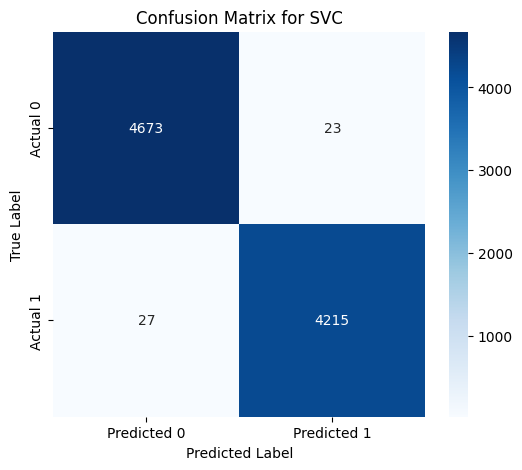

In [65]:
# Generate Confusion Matrix for SVC
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for SVC')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [66]:
# Identify misclassified articles for SVC
misclassified_indices_svm = np.where(y_test != y_pred_svm)[0]

print(f"Total misclassified articles for SVC: {len(misclassified_indices_svm)}\n")

print("First 15 Misclassified Articles (SVC):")
for i, idx in enumerate(misclassified_indices_svm[:15]):
    original_text = X_test_text.iloc[idx]
    actual_label = y_test.iloc[idx]
    predicted_label = y_pred_svm[idx]

    print(f"--- Article {i+1} ---")
    print(f"Original Text: {original_text[:200]}...")
    print(f"Actual Label: {actual_label} ({'True' if actual_label == 1 else 'Fake'})")
    print(f"Predicted Label: {predicted_label} ({'True' if predicted_label == 1 else 'Fake'})")
    print("\n")

Total misclassified articles for SVC: 50

First 15 Misclassified Articles (SVC):
--- Article 1 ---
Original Text: los angeles reuters democratic presidential nominee hillary clinton played strictly deadpan parrying decidedly offthewall question comedian zach galifianakis online parody talk show “ two fern ” relea...
Actual Label: 1 (True)
Predicted Label: 0 (Fake)


--- Article 2 ---
Original Text: well catholic act pope church accepting gruesome hammer sickle christ affixed front wholly offensive pope francis said offended communist crucifix given bolivian president evo morale south american pi...
Actual Label: 0 (Fake)
Predicted Label: 1 (True)


--- Article 3 ---
Original Text: hurricane harvey devastated houston texas irma barreled caribbean way florida two senate florida senator warning u federal emergency management agency fema run disaster assistance funding friday unles...
Actual Label: 0 (Fake)
Predicted Label: 1 (True)


--- Article 4 ---
Original Text: boston reuters year ca

## Save Best Model

In [67]:
import pickle

# Define the filename for the pickle file
model = 'decision_tree_model.pkl'

# Save the model to a pickle file
with open(model, 'wb') as file:
    pickle.dump(dec_tree_model, file)

print(f"Decision Tree Classifier model saved to '{model}'")

Decision Tree Classifier model saved to 'decision_tree_model.pkl'
